<div class="alert alert-block alert-success">
    <h1 align="center">Face Detection & Verification </h1>
    <h3 align="center">RetinaFace - FaceNet</h3>

</div>

<img src="https://wallpapercave.com/wp/wp13830366.jpg" 
     style="width: 100%; max-width: 1200px; height: 450px; object-fit: cover; display: block; margin: 0 auto; border-radius: 8px;">

<div style="
        background-color:#e6f9e6;
        border-left:6px solid #4caf50;
        padding: 20px;
        border-radius: 8px;
        margin: 20px 0;
        font-size: 16px;
        line-height: 1.6; ">
    <h2 style="text-align: center; color: #007400; margin-top: 0;">
        Welcome to my Notebook...! 
    </h2>
           <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li style="margin-bottom:14px;">
The aim of this notebook is to implement an end-to-end face detection and verification system. The pipeline leverages RetinaFace for accurate multi-face detection and landmark extraction, followed by FaceNet to generate deep feature embeddings. Identity verification is mathematically determined by calculating the Cosine Distance between these embeddings.
         </li>
      <li style="margin-bottom:14px;">
For this project, we used a dataset of images from five Iranian female scientists. These clear and high-quality images were used to train and evaluate the face detection and verification models.
         </li>
        </ul>
</div>

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1. Install required libraries
    </p>
</div>

In [1]:
#!pip install deepface

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1.1 Import required libraries
    </p>
</div>

In [3]:
import os
#---
import numpy as np
import cv2 
import matplotlib.pyplot as plt
#---
from deepface import DeepFace
#---
import warnings
warnings.filterwarnings('ignore')
#---
plt.style.use('dark_background')

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1.2 Paths & quick inspect
    </p>
</div>

In [4]:
train_dir = 'Train'
valid_dir = 'valid'
#---
train_filenames = os.listdir(train_dir)
valid_filenames = os.listdir(valid_dir)
names = ['Anousheh Ansari', 'Elham Azizi', 'Maryam Mirzakhani','Mona Jarrahi','Pardis Sabeti']
#---
all_image_paths = []
valid_image_paths = []
target_size = (224, 224) 
#---
for file_name in os.listdir(train_dir):
    full_path = os.path.join(train_dir, file_name)
    all_image_paths.append(full_path)

for file_name in os.listdir(valid_dir):
    full_path = os.path.join(valid_dir, file_name)
    valid_image_paths.append(full_path)
    all_image_paths.append(full_path)

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        2. Data Overview
    </p>
</div>

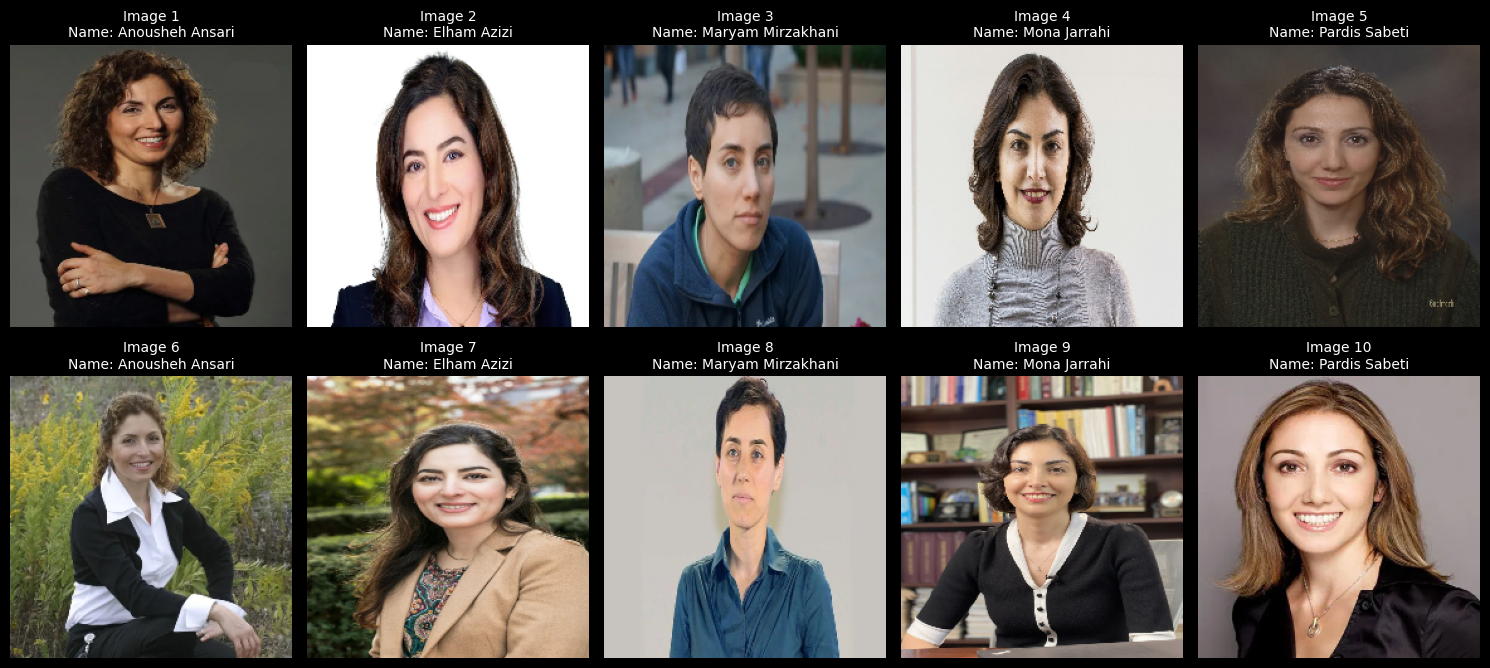

In [5]:
n = 0
plt.figure(figsize=(15, 7))
for i, img in enumerate(all_image_paths):
    
    plt.subplot(2, 5, i + 1)

    img = plt.imread(img)
    img_resized = cv2.resize(img, target_size)
    if n%5==0:
        n=0
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title(f"Image {i + 1}\nName: {names[n]}", size=10)
    n+=1
plt.tight_layout()
plt.show()

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        3. RetinaFace Model For Face Detection
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
             In any face recognition pipeline, the initial phase requires an accurate localized search for facial structures within the image frame. RetinaFace is a state-of-the-art, single-stage face detection framework that achieves superior performance benchmarks. Unlike conventional detectors that only estimate bounding box coordinates, RetinaFace utilizes multi-task learning to simultaneously predict face scores, bounding boxes, and five dense facial landmarks (eyes, nose, and mouth corners). Due to its Feature Pyramid Network (FPN) architecture, the model maintains high localization accuracy even when processing low-resolution, occluded, or multi-angle faces. Consequently, RetinaFace serves as a robust preprocessing module, providing optimally aligned facial crops to the subsequent FaceNet feature extraction layer.
         </li>
        </ul>
</div>





In [6]:
def Face_Detection(image=None, model='retinaface'):
    img_path = image 
    
    detections = DeepFace.extract_faces(img_path=img_path, detector_backend=model)

    img_base = cv2.imread(img_path)
    img_base = cv2.cvtColor(img_base, cv2.COLOR_BGR2RGB)
    
    img_bbox = img_base.copy()
    img_landmarks = img_base.copy()
    
    for face_obj in detections:
        
        confidence = face_obj['confidence']
        x, y, w, h, left_eye, right_eye, nose, mouth_left, mouth_right = face_obj['facial_area'].values()
        
        #Bounding Box
        cv2.rectangle(img_bbox, (x, y), (x + w, y + h), (0, 255, 0), 4)
        
        #Confidence 
        conf_text = f"{confidence*100:.1f}%"
        cv2.putText(img_bbox, conf_text, (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        #Landmarks
        landmarks = [left_eye, right_eye, nose, mouth_left, mouth_right]
        for point in landmarks:
            cv2.circle(img_landmarks, point, 6, (0, 255, 0), -1)

    
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    fig.suptitle(f"Detected Faces: {len(detections)}", fontsize=18, fontweight='bold', y=0.97)
    
    # Bounding Box
    axes[0].imshow(img_bbox)
    axes[0].set_title(f"Face Detection (Bounding Box)", fontsize=14)
    axes[0].axis('off')
    
    # Landmarks
    axes[1].imshow(img_landmarks)
    axes[1].set_title("Landmarks", fontsize=14)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

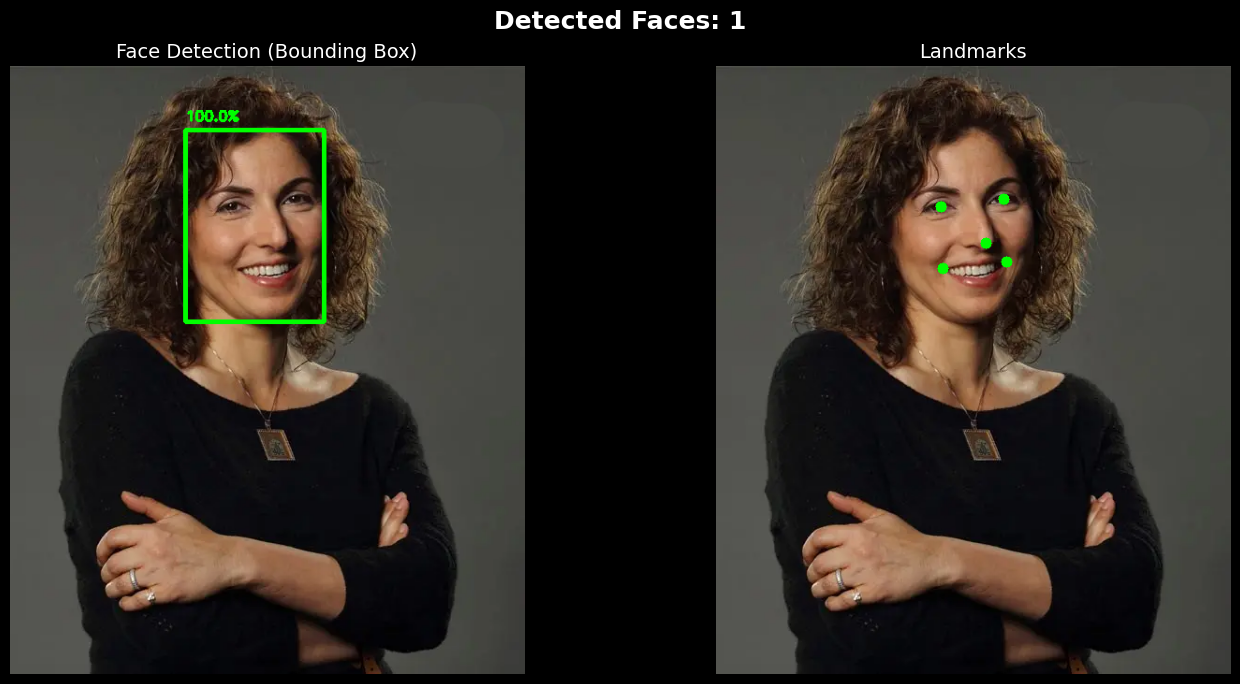

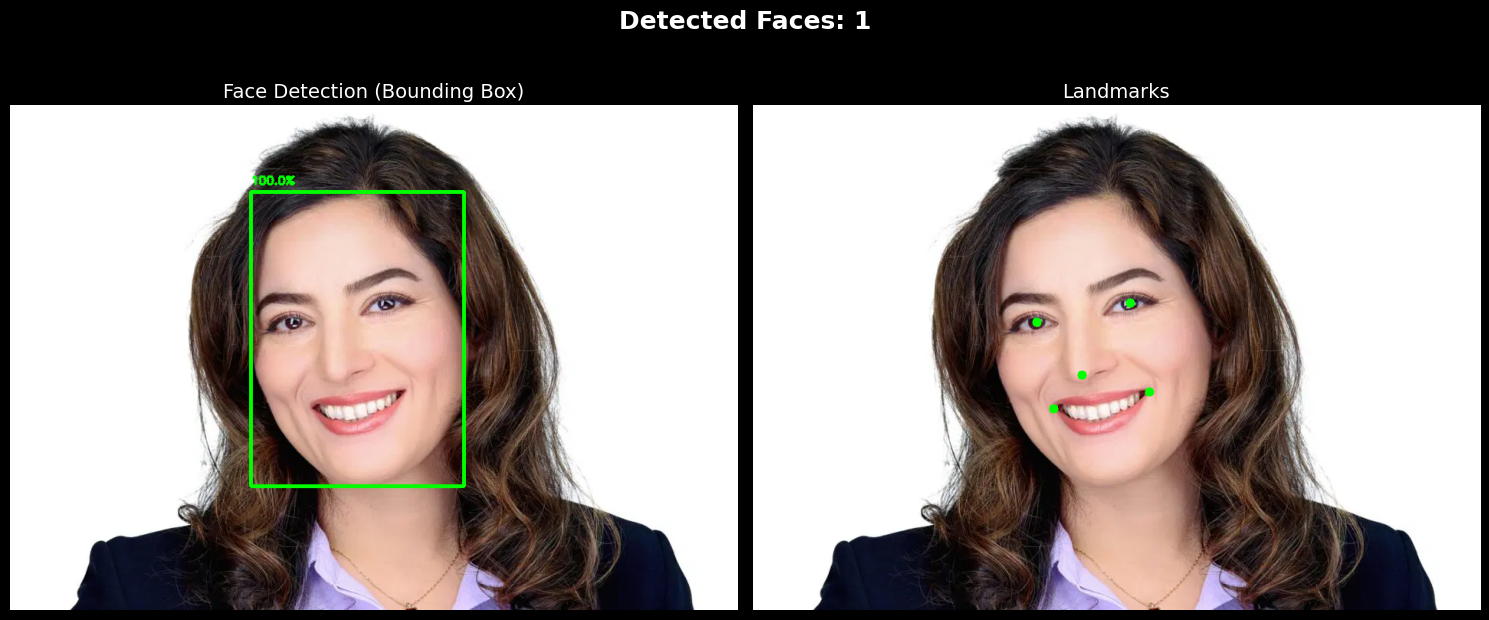

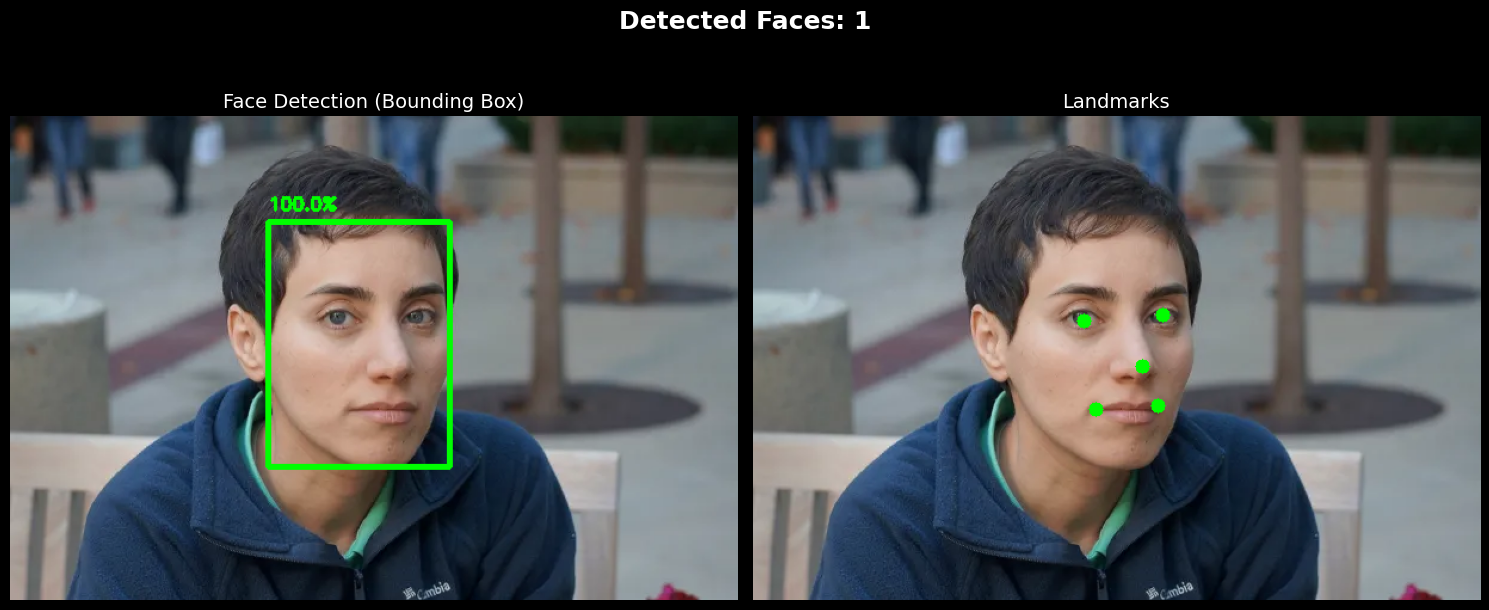

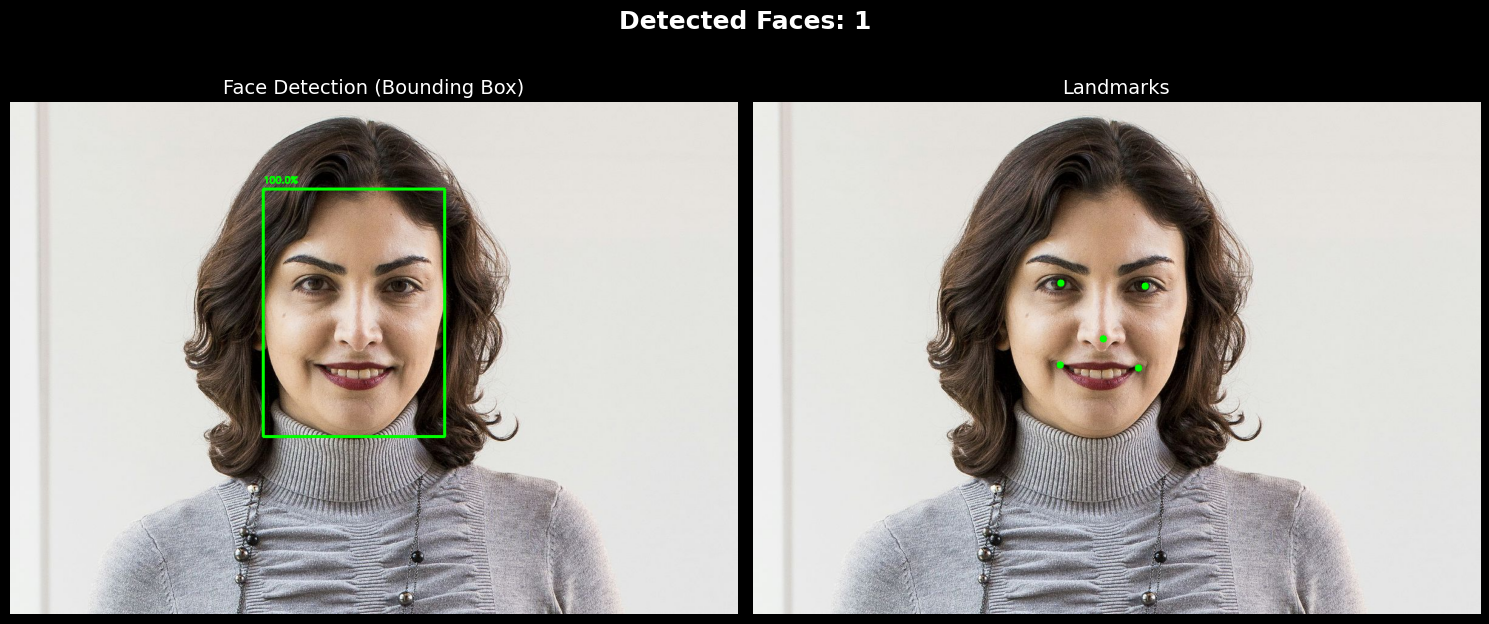

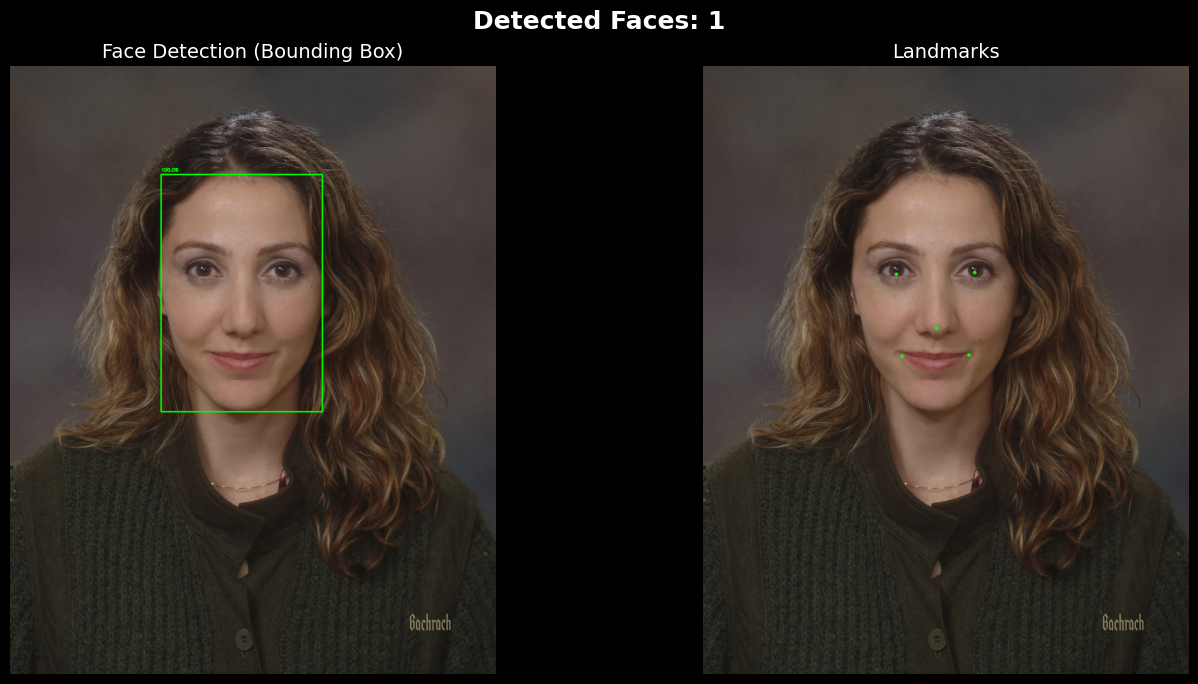

In [7]:
for img in train_filenames:
    Face_Detection(image=f'train/{img}')

<div
    style="
        background-color: #DCFBFC;
        border-left: 6px solid #10B8BC;
        padding: 15px 20px;
        border-radius: 8px;
        margin: 15px 0;
        font-size: 14px;
        line-height: 1.5;
    "
>
    <p style="font-weight: bold; margin-bottom: 10px;">
        Description:
    </p>
    <ul style="margin: 0; padding-left: 20px; text-align: justify;">
        <li>
We saw that all boxes worked well and exat with about 100% accuracy for each and even keypoints were exact.Now for better testing i want to use a picture which is famous and contains a number of faces instead one to evaluate our model when many faces are in image.
        </li>
    </ul>
</div>



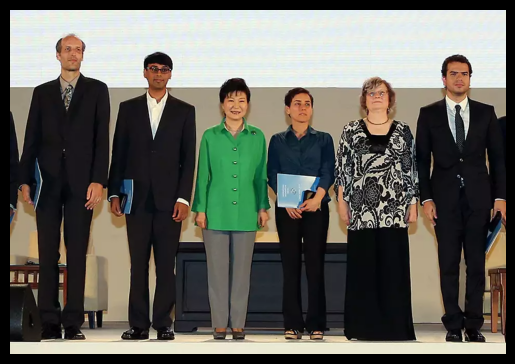

-----------------------------------------------------------------


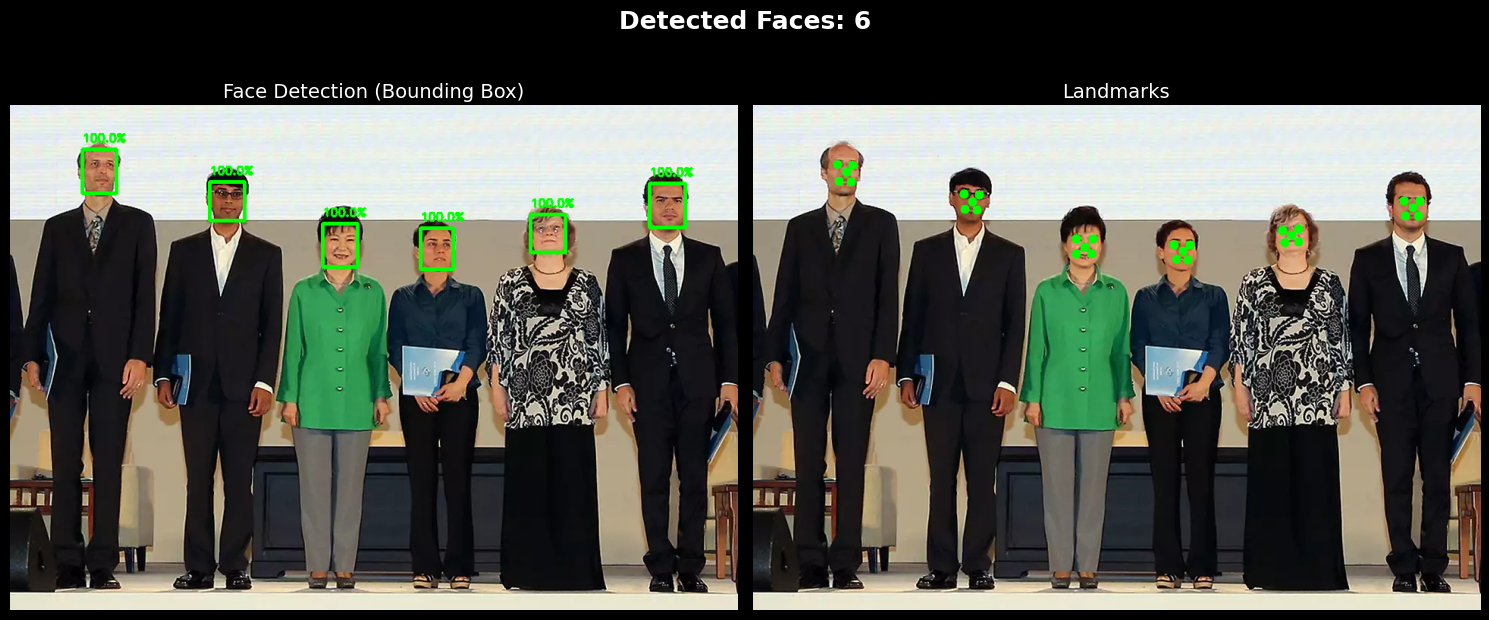

In [8]:
image = plt.imread('image1.png')
plt.imshow(image)
plt.axis('off')
plt.show()
print('-'*65)
Face_Detection(image='image1.png')

<div
    style="
        background-color: #DCFBFC;
        border-left: 6px solid #10B8BC;
        padding: 15px 20px;
        border-radius: 8px;
        margin: 15px 0;
        font-size: 14px;
        line-height: 1.5;
    "
>
    <p style="font-weight: bold; margin-bottom: 10px;">
        Description:
    </p>
    <ul style="margin: 0; padding-left: 20px; text-align: justify;">
        <li>
In this test , we can see the model works perfect and flawless , despite many faces are in image but all of them detected well , even keypoints which were too little found exacl on the faces with acceptable accuracy.
        </li>
    </ul>
</div>



<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        4. Face Detection And Verification - FaceNet Model
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight: bold; margin-bottom: 10px;">
         What is FaceNet?
    </p>
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li style="margin-bottom:14px;">
             FaceNet is a deep learning model designed for face recognition. Instead of analyzing an image pixel by pixel, it processes the cropped face through multiple deep layers to create an Embedding (a face representation).
         </li>
            <li style="margin-bottom:14px;">
Think of an embedding as a compact vector of unique facial features—essentially a digital fingerprint of the face. In large-scale face recognition systems, we don't save heavy images in the database; we only store these feature vectors. When a new image comes in, the system converts it into a vector and compares it against the database to predict who the person is.
         </li>
                        <li style="margin-bottom:14px;">
Triplet Loss: How it Works
In a nutshell, Triplet Loss is the core training algorithm that allows FaceNet to group similar faces together. It works by constantly comparing three images at the same time:
         </li>
        </ul>
    <ol style="margin: 0; padding-left: 45px; text-align: justify;">
        <li style="margin-bottom:14px;">
             Anchor: The target image (the baseline face).
        </li>
         <li style="margin-bottom:14px;">
             Positive: A different image of the exact same person as the Anchor.
        </li>
         <li style="margin-bottom:14px;">
            Negative: An image of a completely different person.
        </li>
    </ol>
    <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li style="margin-bottom:14px;">
The goal of the algorithm is to minimize the "distance" or loss between the Anchor and the Positive images (bringing them closer in math space), while maximizing the distance between the Anchor and the Negative image (pushing them far apart). Triplet Loss calculates these distances using the embedding vectors, ensuring that the final model can accurately tell if two faces match or not.
         </li>
    </ul>
</div>



<center>
<img src="https://www.mdpi.com/jimaging/jimaging-07-00161/article_deploy/html/images/jimaging-07-00161-g001.png" width=1000 height=400 />
</center>

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        4.1 Cosine Similarity
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight: bold; margin-bottom: 10px;">
         What is Cosine Similarity?
    </p>
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li style="margin-bottom:14px;">
Cosine similarity is a mathematical metric used to measure the similarity between two vectors in a multi-dimensional space, particularly in high-dimensional spaces, by calculating the cosine of the angle between them.Note that the direction is important in Cosine Similarity.
            </li>
        </ul>

<p style="font-weight: bold; margin-bottom: 10px;">
          How does Cosine Similarity Work?
    </p>
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li style="margin-bottom:14px;">
Cosine Similarity determins similarity by Cosine of the angle between 2 vectors.In this process, first Dot Product will calculated and based on that the Direction of them will be found.After that the length of each one of them will be calculated.In fact the cosine similarity is the dot product divided by the product of the two vectors lengths.
            </li>
        </ul>
</div>



<center>
<img src="https://miro.medium.com/v2/resize:fit:824/1*GK56xmDIWtNQAD_jnBIt2g.png" width=1000 height=400 />
</center>

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        5. Verifying and Comparing Faces
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li style="margin-bottom:14px;">
             Now, let's wrap the entire pipeline into a single, cohesive function. This function takes two face images, displays them side-by-side with their corresponding titles, and calculates the distance between them.
         </li>
      <li style="margin-bottom:14px;">
For the FaceNet model using Cosine Distance, the default threshold is set around 0.40. In this metric, a smaller distance value indicates a stronger mathematical similarity between the two face vectors. If the calculated distance falls below this threshold, the model confirms that the images belong to the exact same person.
         </li>
        </ul>
</div>


In [9]:
def Verify_Faces(img1_path, img2_path, model='Facenet', detector='retinaface'):
    """
    This function takes two images and checks whether they belong to the same person.
    """
    result = DeepFace.verify(
        img1_path = img1_path, 
        img2_path = img2_path, 
        model_name = model,      
        detector_backend = detector ) 
        
    # Model Results
    is_same = result['verified']       
    distance = result['distance']       
    threshold = result['threshold']     
    
    # Similarity
    similarity = (1 - (distance / threshold)) * 100 if distance < threshold else (1 - distance) * 100
    similarity = max(0, min(100, similarity)) 

    # Read Images
    img1 = cv2.imread(img1_path)
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    #---
    img2 = cv2.imread(img2_path)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    # Plot:
    fig, axes = plt.subplots(1, 2, figsize=(12, 7))
    #---
    if is_same:
        status_text = f"MATCH! Same Person ({similarity:.1f}% Match)"
        title_color = "green"
    else:
        status_text = f"NOT A MATCH! Different People"
        title_color = "red"
    #---    
    fig.suptitle(status_text, fontsize=16, fontweight='bold', color=title_color, y=0.98)

    # Image1
    axes[0].imshow(img1)
    axes[0].set_title("Image 1", fontsize=10)
    axes[0].axis('off')

    # Image2
    axes[1].imshow(img2)
    axes[1].set_title("Image 2", fontsize=10)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

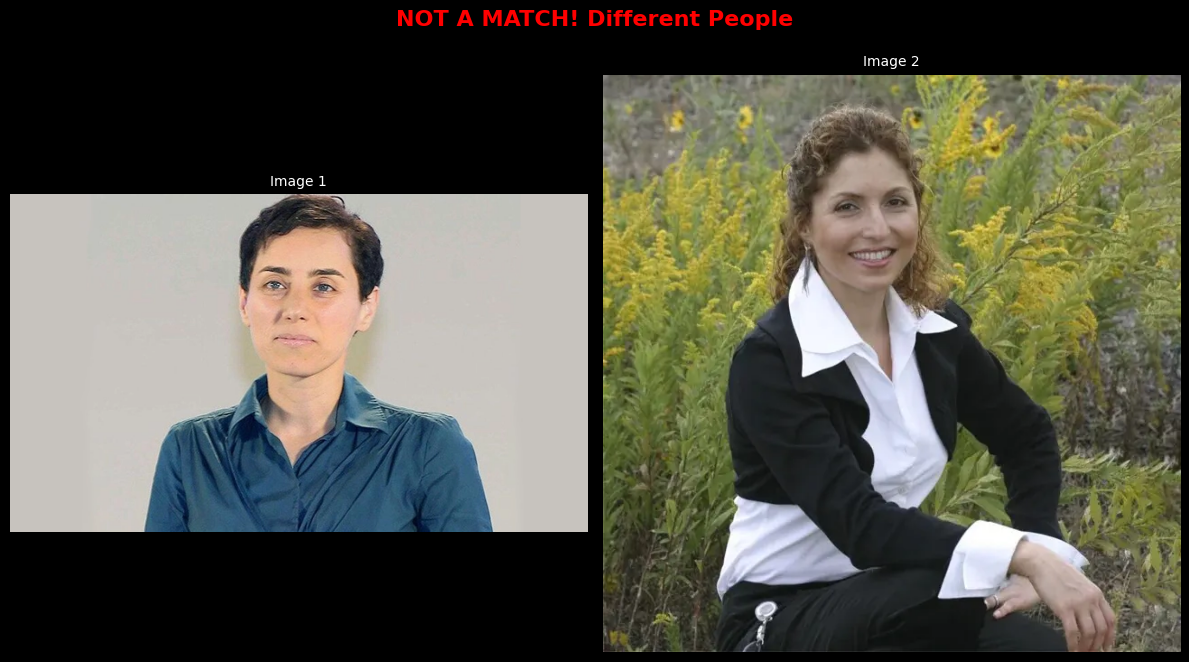

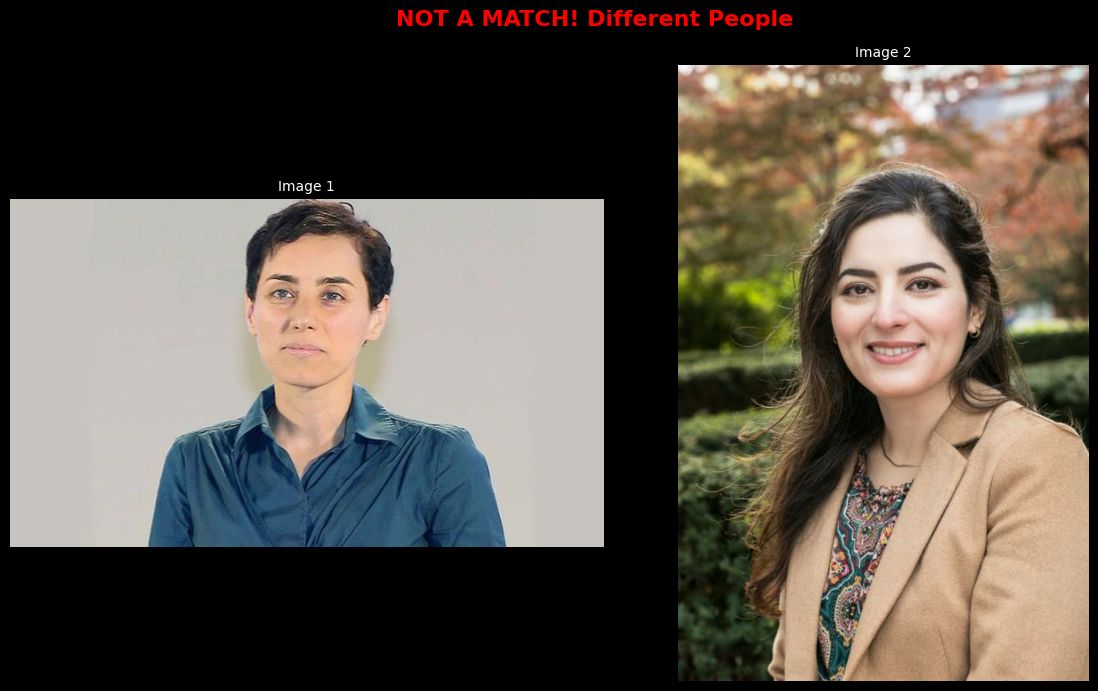

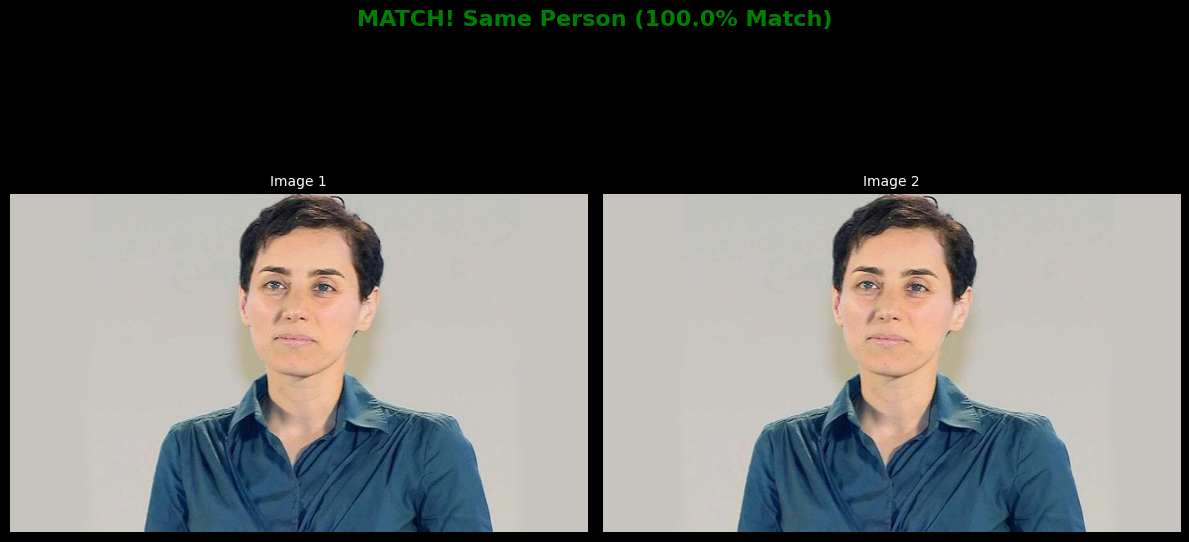

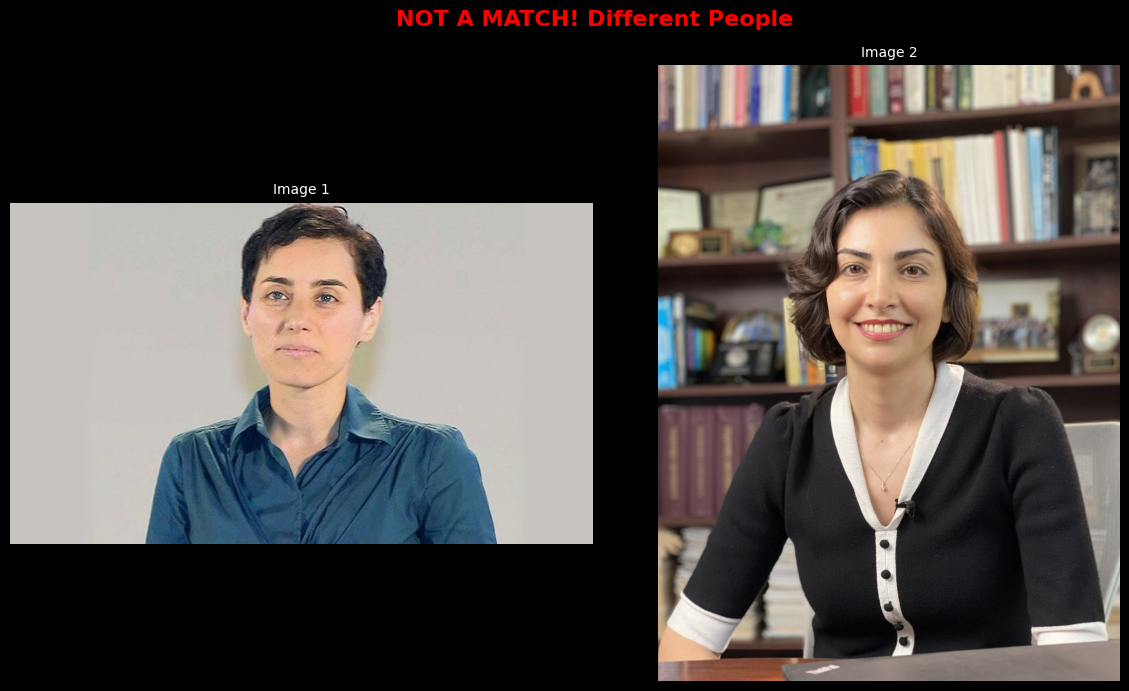

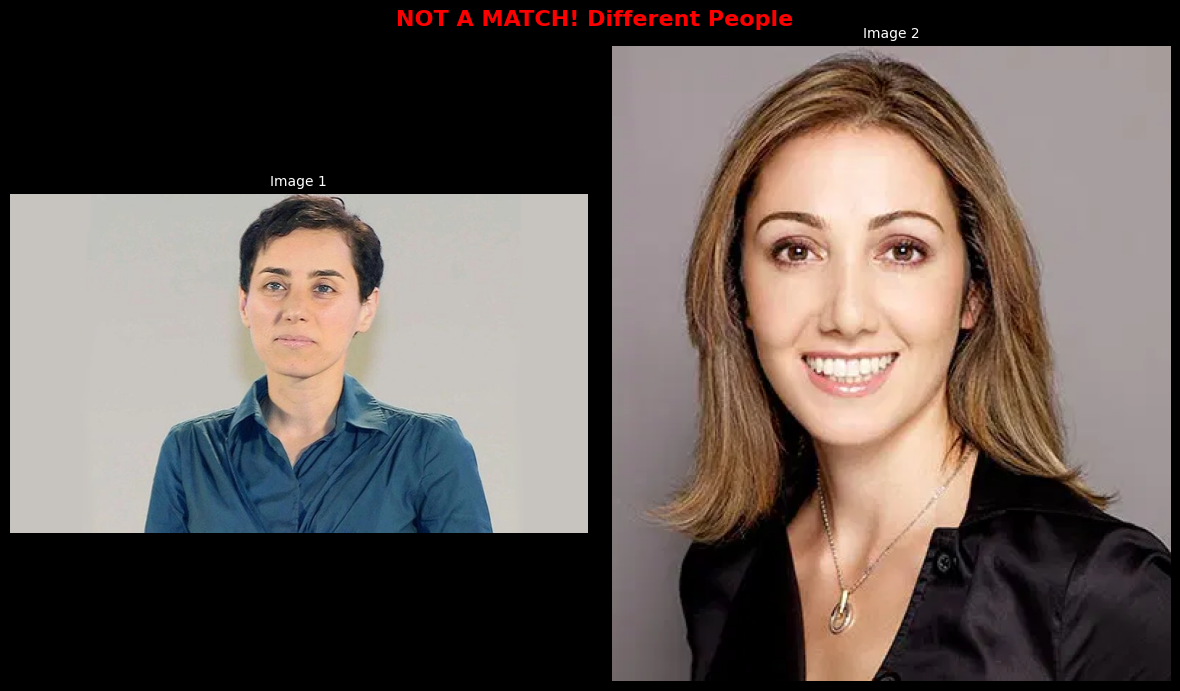

In [10]:
for img in valid_image_paths:
    Verify_Faces(img1_path = valid_image_paths[2] , img2_path = img)

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
       Thanks a lot for going through this notebook! I hope it was helpful and worth your time.
    </p>
</div>